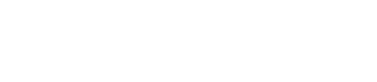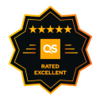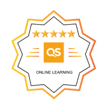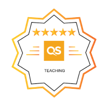

# Machine Learning I · Sesión 2 · Entorno de trabajo y análisis exploratorio de datos

**Universidad EAN · Facultad de Ingeniería · Posgrado**

*Profesor:* Jaime Alberto Ochoa Durán

*Profesor en Inteligencia Artificial · Facultad de Ingeniería*

🔗 [LinkedIn · jaimeochoa-manager](https://www.linkedin.com/in/jaimeochoa-manager/)

## Trazabilidad de la sesión · Session traceability

| Campo | Valor |
|---|---|
| Unidad y código | Machine Learning I · IMVN0004 |
| Programa y modalidad | Especialización en Machine Learning · Maestría en Ciencia de Datos · Maestría en Gerencia en Inteligencia Artificial · Presencial |
| Módulo · Sesión | M1, Fundamentos, metodología y preparación · Sesión 2 de 18 |
| Hilo conductor | Fórmula 1: combustible, la materia prima antes de refinarla |
| Conjunto de datos | Mismo extracto 2019 de siniestros viales de Bogotá, 32 962 filas (Secretaría Distrital de Movilidad, 2021), reconstruido en este cuaderno |
| Fase CRISP-DM | Comprensión de los datos |
| Resultado de aprendizaje | Diagnosticar la calidad de un conjunto de datos, distinguiendo suciedad real de ruido irrelevante |
| Evidencia | Reto acumulativo R2 |
| Nivel cognitivo | Analizar |
| Tiempo | 50 min de ejecución guiada · Reto R2: 2,25 h autónomas |
| Lenguaje y versión | Python 3.11 · pandas, numpy, matplotlib |


## Cómo se trabaja este cuaderno · How to work this notebook

1. Responda cada 🎯 y cada 🔮 **antes** de abrir la solución plegada. Abrirla primero convierte el ejercicio en lectura, no en práctica.
2. Ejecute las celdas en orden. Varias secciones dependen del estado que deja la anterior.
3. Si algo genera un error que el enunciado no anticipó, revise primero el orden de ejecución de las celdas antes de reportarlo: es la causa más frecuente.

## Estructura del cuaderno · Notebook structure

| # | Sección | Marca dominante |
|---|---|---|
| 1 | Recuperar el extracto de 2019 y verificar la reproducibilidad | 🔮 Predice antes de ejecutar |
| 2 | Clasificar las columnas por su escala de medición | 🩺 Depuración guiada |
| 3 | Diagnosticar los faltantes, columna por columna | 🕵️ Error silencioso 1 |
| 4 | Duplicados y redundancia entre columnas | 🕵️ Error silencioso 2 |
| 5 | Desbalance de GRAVEDAD y valores atípicos | 🌐 Exercise in English |
| 6 | Visualización con propósito y síntesis del diagnóstico | 💼 Reto de Negocio de cierre |


## Marcas del cuaderno · Notebook marks

| Marca | Significado |
|---|---|
| 🔁 Repaso | Tres preguntas de la sección anterior |
| 🌱 Analogía | Explicación desde el mundo físico o administrativo, con su límite declarado |
| 🔬 Nota técnica | Profundidad adicional para quien ya programa |
| ⚠️ Error frecuente | El error ruidoso, el que Python reporta |
| 🕵️ Error silencioso | Código que no falla y produce un resultado plausible y falso |
| 🔮 Predice antes de ejecutar | Anticipar el resultado antes de correr la celda |
| 🎯 Ejercicio rápido | Pregunta de discriminación, sin código |
| 🧪 Autocomprobación | Código con verificador sellado |
| 🩺 Depuración guiada | Corregir un error provocado, bajo una restricción |
| 🌐 Exercise in English | Enunciado y respuesta íntegramente en inglés |
| 🛠️ Retos técnicos | Tres niveles: 🟢 guiado, 🟡 aplicado, 🔴 autónomo |
| 💼 Reto de Negocio | Decisión profesional sin código, cinco puntos |
| ✍️ Interpretación | Celda editable para responder el reto de negocio |
| 📚 Referencias | Fuentes APA 7 de la sección |


## Antes de empezar, sus datos · Before you start, your data

Este cuaderno no trae los datos incrustados en el código: vienen aparte, en `ML1_S02_laboratorio_practico_v1.zip`, la carpeta de esta sesión.

1. Descomprima `ML1_S02_laboratorio_practico_v1.zip`. Va a encontrar este cuaderno y el archivo `historico_siniestros_bogota.csv`, el conjunto completo tal como la docencia lo descargó y verificó el 2026-09-20, el mismo archivo crudo que usó la Sesión 1.
2. Suba la carpeta descomprimida a su Google Drive, en cualquier ubicación. El cuaderno busca el archivo por su nombre exacto: lo único que no debe cambiar es el nombre `historico_siniestros_bogota.csv`.
3. Antes de correr la celda de preparación del entorno, intente primero la descarga directa desde el portal oficial: la celda ya lo hace por usted, y solo si esa descarga falla monta su Google Drive y busca el archivo que subió.

## Preparación del entorno · Environment setup

La celda intenta primero descargar el conjunto completo directamente desde el portal oficial. Si esa descarga falla, monta Google Drive y lee el archivo que la docencia ya descargó y verificó. Ninguno de los dos caminos filtra ni limpia nada todavía: el recorte a 2019 y el diagnóstico son contenido visible de este cuaderno.

In [ ]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEMILLA = 2026
np.random.seed(SEMILLA)

# paleta accesible para daltonismo, Okabe-Ito
AZUL = "#0072B2"
NARANJA = "#E69F00"
VERDE = "#009E73"

URL_FUENTE = (
    "https://datosabiertos.bogota.gov.co/dataset/8624f916-1db2-4c17-b669-19a19b35d1ca/"
    "resource/f5862aaa-4e1c-463e-94d5-f04db8164360/download/"
    "historico_siniestros_bogota_d.c_-.csv"
)
NOMBRE_ARCHIVO_RESPALDO = "historico_siniestros_bogota.csv"
FECHA_VERIFICACION_DOCENCIA = "2026-09-20"

try:
    crashes_full = pd.read_csv(URL_FUENTE)
    print(f"Descarga directa desde la fuente oficial: {len(crashes_full)} filas.")
except Exception as e:
    print(f"Descarga directa no disponible ({type(e).__name__}).")
    from google.colab import drive
    drive.mount("/content/drive")

    _coincidencias = glob.glob(
        f"/content/drive/MyDrive/**/{NOMBRE_ARCHIVO_RESPALDO}", recursive=True
    )
    if not _coincidencias:
        raise FileNotFoundError(
            f"No se encontro '{NOMBRE_ARCHIVO_RESPALDO}' en su Google Drive. "
            "Verifique que subio la carpeta descomprimida de "
            "ML1_S02_laboratorio_practico_v1.zip a su Drive, en cualquier ubicacion."
        )
    RUTA_DRIVE = _coincidencias[0]
    print(f"Archivo encontrado en: {RUTA_DRIVE}")
    crashes_full = pd.read_csv(RUTA_DRIVE)
    print(
        f"Se usa el archivo verificado por la docencia el {FECHA_VERIFICACION_DOCENCIA}: "
        f"{len(crashes_full)} filas."
    )

## 1. Recuperar el extracto de 2019 y verificar la reproducibilidad · Recovering the 2019 extract and checking reproducibility

**Al terminar esta sección podrás:**
1. Reconstruir, en una celda visible, el mismo extracto de datos que usó la sesión anterior.
2. Verificar que un proceso determinístico produce exactamente el mismo resultado en dos ejecuciones distintas.
3. Anticipar, antes de ejecutar, si dos cuadernos independientes que parten del mismo archivo crudo deberían coincidir en su forma.
4. **Juzgar** si un resultado reproducible por una sola persona es suficiente evidencia de que el entorno de trabajo es reproducible para todo el equipo.


Que el código corra sin errores no es evidencia de que los datos estén listos. Un conjunto puede superar `.describe()` y `.info()` sin ninguna queja del intérprete y seguir ocultando exactamente la suciedad que compromete cualquier modelo construido sobre él. Esa es la tesis de este cuaderno, y esta primera sección todavía no la pone a prueba: solo recupera el punto de partida.

### 1.1 Por qué este cuaderno reconstruye el extracto otra vez

El Reto R1 de la Sesión 1 ya trabajó sobre el extracto de 2019. Este cuaderno recibe, dentro de su propio `.zip`, el mismo archivo crudo completo, sin depender de que exista ningún archivo intermedio de la Sesión 1: cada sesión de este módulo reconstruye el mismo recorte, de forma visible, a partir del mismo crudo. Es la manera de que cualquier persona del equipo, con cualquier `.zip` de las cuatro sesiones de este módulo, llegue exactamente al mismo punto de partida.

In [ ]:
print("Filas totales, 2015 a 2021:", crashes_full.shape[0])
crashes = crashes_full[crashes_full["ANO_OCURRENCIA_ACC"] == 2019].copy()
print("Filas del extracto 2019:", len(crashes))

#### 🌱 Analogía · El mismo tanque de combustible, dos boxes distintos

Dos equipos de un mismo campeonato pueden recibir combustible del mismo lote y analizarlo en sus propios boxes, con sus propios instrumentos, sin necesitar el laboratorio del otro equipo. **Dónde se rompe:** un lote de combustible se agota al usarse; un archivo de datos se puede copiar y analizar en paralelo tantas veces como haga falta, sin que una copia interfiera con la otra.

### 1.2 Retomando el Reto R1

El Reto R1 clasificó el problema de priorización de intervenciones viales como aprendizaje supervisado, con `GRAVEDAD` como variable objetivo candidata, y encontró que seis columnas superaban la prueba de no ser identificadoras. Esa formulación se acepta como punto de partida, no como verdad definitiva: en un proyecto real, el encuadre inicial del problema se revisa a la luz de cada fase nueva de CRISP-DM, y la comprensión de los datos es precisamente la fase que puede obligar a ajustarlo.

Esta sesión no cuestiona el paradigma elegido: verifica si el conjunto, tal como llegó, está en condiciones de sostenerlo. Puede ocurrir, y de hecho va a ocurrir más adelante en este cuaderno, que una variable que parecía perfectamente utilizable esconda un problema que solo un diagnóstico columna por columna revela.

### 🔮 Predice antes de ejecutar 1

Sin ejecutar la siguiente celda: ¿`crashes.shape` de este cuaderno va a coincidir exactamente con el `crashes.shape` que reportó el cuaderno de la Sesión 1, a pesar de haberse reconstruido de forma completamente independiente? Responda antes de correr la celda.

In [ ]:
crashes.shape

<details><summary>Ver la explicación</summary>

Sí coincide: `(32962, 16)` en ambos cuadernos. El filtro `ANO_OCURRENCIA_ACC == 2019` es determinístico, sin ningún componente aleatorio, así que aplicado sobre el mismo archivo crudo produce siempre el mismo resultado, sin importar quién lo ejecute ni en qué orden. Esta es la razón por la que `SEMILLA = 2026` se declara por convención de la unidad, aunque este filtro específico no la necesite: no toda operación reproducible depende de una semilla, pero toda operación reproducible sí depende de partir del mismo archivo.
</details>

### 🎯 Ejercicio rápido 1

Un(a) compañero(a) de equipo dice: «da igual, cualquier archivo `historico_siniestros_bogota.csv` sirve, mientras tenga ese nombre». ¿Qué riesgo concreto tiene aceptar esa afirmación sin revisión?

<details><summary>Ver la solución</summary>

El riesgo es que un archivo distinto, con el mismo nombre pero descargado en otra fecha o desde otra fuente, podría tener un número de filas distinto, columnas renombradas, categorías codificadas de otra manera o una actualización de los datos que el portal haya publicado después. `pandas` no valida el contenido de un archivo antes de leerlo, solo su formato: un CSV con la estructura correcta pero con datos distintos se carga sin ningún aviso, y el error aparecería, si acaso, muchas celdas más adelante, cuando algún cálculo diera un resultado que no cuadra con lo que otro integrante del equipo obtuvo.

La reproducibilidad no depende solo del nombre del archivo, sino de que sea el mismo archivo, byte a byte, verificado por la docencia el 2026-09-20, la fecha declarada en la celda de preparación del entorno. Por eso esa fecha se declara de forma explícita en el código y no solo en la prosa: es el ancla que permite, ante una discrepancia futura, distinguir entre un error del equipo y un cambio real en la fuente de datos.
</details>

### 🧪 Autocomprobación 1

Calcule en `resultado` cuántas columnas del extracto son de tipo `float64`. Use `crashes.dtypes`.

In [ ]:
# ESCRIBE TU CODIGO AQUI
resultado = None


# --- No modifiques nada por debajo de esta línea ----------------------
_ref = int((crashes.dtypes == "float64").sum())
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que estes contando sobre crashes.dtypes, no sobre crashes.columns.")
else:
    print(f"\u2705 Correcto. Hay {_ref} columnas de tipo float64.")

### 🛠️ Retos técnicos 1

🟢 **Nivel 1, guiado.** Muestre `crashes.columns` completo.

*Criterio de logro:* el resultado lista exactamente 16 nombres de columna.

In [ ]:
# 🟢 Nivel 1, guiado
# Escribe tu código aquí...

🟡 **Nivel 2, aplicado.** Verifique, con código, que `crashes` no comparte memoria con `crashes_full` usando `.copy()` en algún punto de la celda 1.1 ya lo garantizó; en vez de eso, confirme con código que `crashes["ANO_OCURRENCIA_ACC"].unique()` contiene un solo valor.

*Criterio de logro:* el resultado es un arreglo con el único valor 2019.

In [ ]:
# 🟡 Nivel 2, aplicado
# Escribe tu código aquí...

🔴 **Nivel 3, autónomo.** Decida si, para que otra persona del equipo reproduzca exactamente este cuaderno, basta con compartir el `.ipynb`, o si además necesita el `.zip` completo. Nombre qué se rompe si comparte solo el `.ipynb`.

*Criterio de logro:* la respuesta nombra explícitamente que sin el archivo de datos la celda de preparación del entorno falla en ambos caminos, descarga directa y respaldo de Drive, si la fuente oficial no está disponible ese día.

📚 Recurso de profundización: Wilson, G., Bryan, J., Cranston, K., Kitzes, J., Nederbragt, L., y Teal, T. K. (2017). Good enough practices in scientific computing. *PLOS Computational Biology, 13*(6), e1005510.

In [ ]:
# 🔴 Nivel 3, autonomo
# Escribe tu código aquí...

### 💼 Reto de Negocio 1

Un(a) integrante del equipo propone empezar a interpretar resultados hoy mismo, sin esperar a que las tres personas del equipo confirmen que su copia del extracto tiene exactamente 32 962 filas.

**Decisión principal.** ¿Se avanza con el diagnóstico ya, confiando en que todos descargaron el mismo archivo, o se dedican cinco minutos a que cada persona confirme `crashes.shape` antes de seguir?

**Quién resulta perjudicado.** Si se avanza sin confirmar y alguien tiene un archivo distinto, ese integrante reporta cifras que nadie más puede reproducir, y el equipo pierde tiempo después reconciliando resultados contradictorios. Si se detiene el equipo cinco minutos, se pierde algo de tiempo de análisis.

**Indicador y por qué no el obvio.** El indicador obvio es «todos dicen que ya tienen los datos». El indicador necesario es que las tres personas reporten el mismo `crashes.shape` por escrito, no solo de palabra.

**Objeción externa.** Alguien podría decir que verificar esto es desconfiar del equipo. La respuesta: verificar reproducibilidad no es desconfianza, es una práctica estándar de cómputo científico (Wilson et al., 2017), igual de rutinaria que revisar que el auto arranca antes de salir a pista.

**Límite del análisis.** Confirmar que `crashes.shape` coincide no garantiza que el contenido de cada celda coincida también: es una verificación necesaria, no suficiente.

Fase de CRISP-DM: comprensión de los datos, donde se establece la base común sobre la que el resto del ciclo se apoya (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 1

*(Doble clic para editar.)*

**Mi decisión:** [una frase]

**Quién queda perjudicado si me equivoco:** [una frase]

**Indicador que usaría y por qué no el obvio:** [dos a tres frases]

**Cómo respondo a la objeción:** [dos a tres frases]

**Qué no puedo saber con esta verificación:** [una frase]

### 📚 Referencias de la sección 1

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Secretaría Distrital de Movilidad. (2021). *Historico Siniestros Bogotá D.C* [Conjunto de datos]. Datos Abiertos Bogotá. Recuperado el 20 de septiembre de 2026, de https://datosabiertos.bogota.gov.co/dataset/historico-siniestros-bogota-d-c

Wilson, G., Bryan, J., Cranston, K., Kitzes, J., Nederbragt, L., y Teal, T. K. (2017). Good enough practices in scientific computing. *PLOS Computational Biology, 13*(6), e1005510. https://doi.org/10.1371/journal.pcbi.1005510

## 2. Clasificar las columnas por su escala de medición · Classifying columns by measurement scale

**Al terminar esta sección podrás:**
1. Clasificar una columna como identificadora verificando que su número de valores únicos iguala el número de filas.
2. Clasificar el resto de columnas en nominal, ordinal, discreta o continua.
3. Reconocer cuándo el tipo de dato que pandas infiere no coincide con la naturaleza real de la columna.
4. **Diseñar** un criterio de exclusión de columnas antes de calcular un solo estadístico.


### 🔁 Repaso

1. ¿Por qué `crashes.shape` coincide entre este cuaderno y el de la Sesión 1, a pesar de reconstruirse por separado?
2. ¿Cuál es la tesis de este cuaderno, en una frase?
3. ¿Qué variable objetivo candidata heredó esta sesión del Reto R1?

<details><summary>Ver las respuestas</summary>

1. Porque el filtro `ANO_OCURRENCIA_ACC == 2019` es determinístico y ambos cuadernos parten del mismo archivo crudo verificado.
2. Que el código corra sin errores no es evidencia de que los datos estén listos.
3. `GRAVEDAD`.
</details>

### 2.1 Identificadores: la prueba de valores únicos

La Sesión 1 ya estableció esta prueba, y esta subsección la retoma porque clasificar columnas por su escala de medición, el objetivo de esta sección, exige primero descartar las que no tienen escala alguna. Un identificador es una columna cuyo único propósito es distinguir una fila de otra: no describe el fenómeno, describe el registro, y por eso no pertenece a ninguna de las categorías de medición que se van a introducir a continuación, ni nominal, ni ordinal, ni discreta, ni continua. La prueba es sencilla: si el número de valores únicos de una columna iguala el número de filas, esa columna no puede repetir ningún valor, y por lo tanto no puede agrupar nada.

In [ ]:
for col in ["OBJECTID", "FORMULARIO", "CODIGO_ACCIDENTE"]:
    print(f"{col:<20}{crashes[col].nunique():>8} valores unicos de {len(crashes)} filas")

Las tres columnas tienen exactamente tantos valores únicos como filas: son identificadores, se excluyen de cualquier diagnóstico estadístico y de cualquier futura lista de predictoras.

#### ⚠️ Error frecuente

Escribir el nombre de una columna con una mayúscula distinta a la real produce un error ruidoso e inmediato:

In [ ]:
crashes["Gravedad"].value_counts()

Python detiene la ejecución con un `KeyError` y señala exactamente qué nombre no encontró. Es un error incómodo, pero honesto. El error de la siguiente subsección es exactamente lo contrario: no detiene nada.

### 2.2 Cuando el tipo de dato de pandas no coincide con la naturaleza real de la columna

La escala de medición de una variable, nominal, ordinal, discreta o continua, es una propiedad estadística del fenómeno que describe, no del tipo de dato que un lenguaje de programación le asigna al leerla. Ambas cosas suelen coincidir, pero no siempre, y esa discrepancia es una fuente silenciosa de errores de preparación más adelante en la unidad.

`crashes.dtypes` clasifica `FECHA_HORA_ACC` como `object`, es decir, texto, no como fecha. Pandas infiere el tipo de una columna a partir de cómo están escritos sus valores en el archivo crudo, y una fecha escrita como cadena de caracteres se ve, para ese propósito, igual que cualquier otro texto: pandas no sabe que esa cadena representa una fecha hasta que alguien se lo dice explícitamente. Esa conversión formal es tarea de preparación de datos, reservada a la Sesión 3; aquí solo se diagnostica el problema, no se corrige, porque comprender los datos antes de tocarlos es, precisamente, la fase en la que está parada esta sesión.

### 🩺 Depuración guiada 1

Un(a) compañero(a) quiere saber qué años de fecha y hora trae la columna, y escribe esta celda:

In [ ]:
crashes["FECHA_HORA_ACC"].dt.year.value_counts()

**Restricción para corregirla:** sin usar `pd.to_datetime()` todavía. Esa conversión formal de tipo es contenido de la Sesión 3; esta sesión solo diagnostica.

<details><summary>Ver la corrección</summary>

```python
crashes["FECHA_HORA_ACC"].str[:4].value_counts().sort_index()
```

`FECHA_HORA_ACC` es de tipo `object`, así que no tiene el accesor `.dt`, exclusivo de columnas ya convertidas a fecha: pandas lanza `AttributeError`. Tratándola como lo que realmente es, una cadena de texto, se puede leer el año igual, tomando los primeros cuatro caracteres, sin convertir todavía el tipo de toda la columna.
</details>

### 2.3 Las cuatro escalas de medición del extracto

Toda variable de un conjunto de datos admite una clasificación según cuánta estructura matemática tienen sus valores, y esa estructura, no la costumbre ni la conveniencia, es la que determina qué estadístico y qué gráfico son válidos para ella (Wickham, 2014). Hay cuatro escalas. La **nominal** solo distingue categorías, sin ningún orden entre ellas: preguntar si una localidad es «mayor» que otra no tiene sentido. La **ordinal** sí admite un orden, pero no una distancia numérica confiable entre sus niveles: se puede decir que una categoría es más grave que otra, pero no que sea exactamente el doble de grave. La **discreta** toma valores numéricos contables, típicamente enteros, sobre los que sí tienen sentido operaciones como el promedio. La **continua** toma cualquier valor dentro de un rango, con distancias numéricas plenamente interpretables.

Confundir estas escalas tiene consecuencias concretas: calcular un promedio sobre una variable nominal no produce un error de Python, pero produce un número sin ningún significado, exactamente el error que la Sesión 1 ya mostró con `GRAVEDAD` y `.mean()`.

| Escala | Ejemplo en el extracto |
|---|---|
| Nominal, sin orden | `LOCALIDAD`, `CLASE_ACC` |
| Ordinal, con orden | `GRAVEDAD`, interpretada como severidad creciente |
| Discreta | `ANO_OCURRENCIA_ACC` |
| Continua | `LATITUD`, `LONGITUD`, `X`, `Y`, `CIV`, `PK_CALZADA` |


In [ ]:
numeric_cols = crashes.select_dtypes(include="number").columns.tolist()
object_cols = crashes.select_dtypes(include="object").columns.tolist()
print("Columnas numericas:", len(numeric_cols), numeric_cols)
print("Columnas de texto:", len(object_cols), object_cols)

`select_dtypes` clasifica por el tipo que pandas infirió, no por la escala de medición real: agrupa `OBJECTID` junto con `LATITUD` porque ambas son numéricas, aunque una sea un identificador y la otra una coordenada continua. La clasificación de la tabla de arriba, hecha con criterio y no solo con `dtypes`, es la que gobierna el resto del diagnóstico.

### 🎯 Ejercicio rápido 2

`ANO_OCURRENCIA_ACC` es de tipo `int64` en este extracto de un solo año. ¿Debería tratarse como variable discreta numérica en un futuro modelo con varios años de datos, o como variable categórica?

<details><summary>Ver la solución</summary>

Depende de si el orden y la distancia entre años importan para la pregunta de negocio, y esa decisión no la resuelve el tipo de dato `int64` por sí solo. Si interesa una tendencia a lo largo del tiempo, por ejemplo si la siniestralidad crece o decrece año tras año, se trata como discreta numérica, porque ahí sí importa que 2021 esté a una distancia de dos unidades de 2019. Si en cambio interesa comparar años como bloques administrativos, por ejemplo antes y después de un cambio de normativa vial, sin asumir que el efecto crece de forma lineal año tras año, conviene tratarla como categórica.

Con un solo año en este extracto, la pregunta todavía no tiene evidencia para resolverse: una variable con un único valor no puede mostrar tendencia ni comparación alguna. Esto es un recordatorio útil de que la escala de medición correcta de una variable a veces depende de cuántos valores distintos hay disponibles para observar, no solo de su naturaleza teórica.
</details>

### 🧪 Autocomprobación 2

Calcule en `resultado` la lista, ordenada alfabéticamente, de las columnas numéricas que **no** son identificadores. Use `numeric_cols` y excluya `OBJECTID` y `CODIGO_ACCIDENTE`.

In [ ]:
# ESCRIBE TU CODIGO AQUI
resultado = None


# --- No modifiques nada por debajo de esta línea ----------------------
_ref = sorted(c for c in numeric_cols if c not in {"OBJECTID", "CODIGO_ACCIDENTE"})
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que excluyas solo los identificadores numericos.")
else:
    print(f"\u2705 Correcto. {len(_ref)} columnas numericas no identificadoras: {_ref}")

### 🛠️ Retos técnicos 2

🟢 **Nivel 1, guiado.** Muestre `crashes["CLASE_ACC"].unique()`.

*Criterio de logro:* el resultado lista exactamente 6 categorías distintas.

In [ ]:
# 🟢 Nivel 1, guiado
# Escribe tu código aquí...

🟡 **Nivel 2, aplicado.** Extraiga el mes, como texto de dos caracteres, de `FECHA_HORA_ACC` sin usar `pd.to_datetime()`, siguiendo el patrón de la depuración guiada.

*Criterio de logro:* el resultado tiene valores entre `"01"` y `"12"`.

In [ ]:
# 🟡 Nivel 2, aplicado
# Escribe tu código aquí...

🔴 **Nivel 3, autónomo.** Decida si `CIV`, código de identificación vial del IDECA, es un identificador en el sentido de la sección 2.1, a pesar de su nombre. Verifique con código antes de responder.

*Criterio de logro:* la respuesta reporta el número de valores únicos de `CIV` frente al número de filas y concluye, con ese dato, si es o no identificador.

📚 Recurso de profundización: Wickham, H. (2014). Tidy data. *Journal of Statistical Software, 59*(10), 1-23.

In [ ]:
# 🔴 Nivel 3, autonomo
# Escribe tu código aquí...

### 💼 Reto de Negocio 2

El área de sistemas de la Secretaría propone convertir automáticamente toda columna numérica en variable de modelado, sin revisión manual, para «ahorrar tiempo de ingeniería».

**Decisión principal.** ¿Se acepta la conversión automática de todas las columnas numéricas, o se exige la clasificación manual por escala de medición de esta sección antes de aceptar cualquier columna?

**Quién resulta perjudicado.** Si se acepta la automatización, cualquier modelo futuro puede terminar usando `OBJECTID` o `CODIGO_ACCIDENTE` como si fueran predictoras legítimas, lo que perjudica a quienes confían en las predicciones del modelo en producción. Si se exige revisión manual, el equipo de ingeniería pierde velocidad.

**Indicador y por qué no el obvio.** El indicador obvio es el tipo de dato que pandas infiere. El indicador necesario es la prueba de valores únicos de la sección 2.1, que el tipo de dato por sí solo no aplica.

**Objeción externa.** El área de sistemas podría insistir en que revisar columna por columna no escala a conjuntos con cientos de variables. La respuesta: la prueba de valores únicos sí se automatiza, lo que no se automatiza sin riesgo es aceptar el resultado sin que una persona lo revise al menos una vez por conjunto de datos nuevo.

**Límite del análisis.** Esta clasificación es válida para el extracto de 2019; un conjunto de otro año o de otra ciudad exigiría repetir la verificación, no asumir la misma clasificación.

Fase de CRISP-DM: comprensión de los datos, donde se decide qué columnas entran siquiera a la conversación de modelado (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 2

*(Doble clic para editar.)*

**Mi decisión:** [una frase]

**Quién queda perjudicado si me equivoco:** [una frase]

**Indicador que usaría y por qué no el obvio:** [dos a tres frases]

**Cómo respondo a la objeción:** [dos a tres frases]

**Qué no puedo saber con este análisis:** [una frase]

### 📚 Referencias de la sección 2

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61.

Wickham, H. (2014). Tidy data. *Journal of Statistical Software, 59*(10), 1-23.

## 3. Diagnosticar los faltantes, columna por columna · Diagnosing missing values, column by column

**Al terminar esta sección podrás:**
1. Calcular el porcentaje de faltantes de cada columna.
2. Distinguir un resumen agregado de un diagnóstico columna por columna.
3. Nombrar, sin resolverlo todavía, qué mecanismo de ausencia es plausible para un patrón de faltantes dado.
4. **Juzgar** si un promedio general de faltantes sobre todo el conjunto es información útil o es ruido que esconde el problema real.


### 🔁 Repaso

1. ¿Qué prueba distingue una columna identificadora de una que no lo es?
2. ¿Por qué `crashes["FECHA_HORA_ACC"].dt.year` lanzó un error?
3. ¿Qué columnas del extracto son continuas, según la clasificación de la sección 2?

<details><summary>Ver las respuestas</summary>

1. Que su número de valores únicos iguale el número de filas.
2. Porque `FECHA_HORA_ACC` es de tipo `object`, texto, y el accesor `.dt` solo existe en columnas ya convertidas a fecha.
3. `LATITUD`, `LONGITUD`, `X`, `Y`, `CIV` y `PK_CALZADA`.
</details>

### 3.1 Porcentaje de faltantes por columna

Un valor faltante es una celda sin dato, registrada por pandas como `NaN` (*not a number*). Antes de decidir qué hacer con un faltante, tarea de la Sesión 3, hace falta medir cuánto hay y dónde: sin ese diagnóstico previo, cualquier estrategia de tratamiento se elige a ciegas. El porcentaje de faltantes de una columna se calcula como el conteo de nulos dividido entre el total de filas, multiplicado por cien, y esa cifra debe calcularse **columna por columna**, nunca como un solo número para todo el conjunto: el resto de esta sección muestra por qué.

In [ ]:
faltantes = (crashes.isna().mean() * 100).sort_values(ascending=False)
faltantes[faltantes > 0]

Solo tres columnas tienen algún faltante: `PK_CALZADA` con 19,94 % (6 572 filas), `CIV` con 0,27 % (90 filas) y `LOCALIDAD` con apenas 0,006 % (2 filas). Las otras trece columnas no tienen ni un solo valor ausente.

#### 🌱 Analogía de Fórmula 1 · Combustible

Si los datos son el petróleo del siglo XXI, este extracto es el combustible sin refinar: todavía no se sabe qué octanaje tiene ni qué impurezas trae. Esta sesión diagnostica el crudo, columna por columna; refinarlo con imputación, codificación y escalamiento es tarea de la Sesión 3. **Dónde se rompe:** la refinación real no distingue el octanaje por tipo de motor de forma tan selectiva como el escalamiento distingue entre algoritmos, una particularidad estadística sin equivalente mecánico limpio.

### 3.2 Un promedio que parece tranquilizador

Antes de mirar la tabla columna por columna, alguien podría resumir la situación con un solo número: el faltante promedio de todo el conjunto.

### 🕵️ Error silencioso 1

Una manera habitual, y aparentemente razonable, de resumir «qué tan sucio» está un conjunto es promediar el porcentaje de faltantes de todas sus columnas:

In [ ]:
promedio_general_faltantes = crashes.isna().mean().mean() * 100
print(f"Faltante promedio del conjunto: {promedio_general_faltantes:.2f} %")

La celda no falla, y el número que produce, 1,26 %, suena tranquilizador: parecería que el conjunto está prácticamente completo.

<details><summary>🕵️ Qué ocurrió, por qué nadie avisó, y la corrección</summary>

**Qué ocurrió.** El promedio de 1,26 % se calcula sobre 16 columnas, 13 de las cuales tienen 0 % de faltantes. Ese 1,26 % es el resultado de diluir el 19,94 % de `PK_CALZADA` entre trece columnas perfectas: el promedio aritmético trata cada columna como si pesara lo mismo para la decisión de negocio, cuando en realidad una sola columna concentra casi todo el problema.

**Por qué nadie avisó.** `.mean()` sobre `.mean()` es una operación perfectamente válida en pandas: no hay ningún error de sintaxis ni de tipo que Python pueda detectar. El código hace exactamente lo que se le pidió, calcular un promedio, y un promedio no tiene manera de saber que la pregunta correcta era otra.

**La corrección.** El diagnóstico de faltantes se reporta siempre columna por columna, como en la sección 3.1, nunca como un solo promedio agregado. Un promedio general puede usarse como resumen ejecutivo, pero solo después de haber revisado la tabla completa, no en su lugar.

**Conexión con el otro error silencioso del cuaderno.** El error silencioso 2, en la sección 4, muestra el problema inverso: una prueba demasiado estricta, en vez de demasiado agregada, que también esconde la verdad, aunque por una razón distinta. Ambos comparten la misma tesis: un código que corre sin errores no garantiza que la pregunta que se le hizo a los datos fuera la correcta.
</details>

### 3.3 El mecanismo de ausencia, una pregunta abierta

Que `PK_CALZADA` concentre el faltante no dice todavía **por qué** falta, y esa pregunta tiene un nombre técnico y tres respuestas posibles, clasificadas según el mecanismo estadístico que las produce (Kaufman et al., 2012). Un faltante es **completamente al azar** (*missing completely at random*, MCAR) cuando la probabilidad de faltar no depende de ninguna variable, observada o no: cualquier fila tiene la misma chance de perder ese dato. Es **al azar condicionado** (*missing at random*, MAR) cuando la probabilidad de faltar depende de otra variable que sí está en el conjunto, por ejemplo si faltara más en ciertas localidades. Y es **no al azar** (*missing not at random*, MNAR) cuando la probabilidad de faltar depende del propio valor que falta, por ejemplo si `PK_CALZADA` faltara justo en los siniestros sin un punto exacto de referencia en la vía, el tipo de caso donde el dato sería más difícil de registrar en primer lugar.

Distinguir entre estos tres mecanismos importa porque cada uno admite un tratamiento distinto en la Sesión 3: ignorar la diferencia y aplicar la misma receta a los tres casos es, en sí mismo, una fuente de sesgo. Esta sesión no resuelve todavía cuál mecanismo aplica a `PK_CALZADA`: reúne la evidencia necesaria para argumentarlo.

In [ ]:
faltante_pk_por_localidad = (
    crashes.groupby("LOCALIDAD")["PK_CALZADA"].apply(lambda s: s.isna().mean() * 100)
)
faltante_pk_por_localidad.sort_values(ascending=False).head(5)

El porcentaje de faltante de `PK_CALZADA` varía notablemente entre localidades, lo que sugiere que el faltante no es puramente aleatorio: es más consistente con un mecanismo asociado a dónde ocurre el siniestro que con un descuido uniforme de captura.

### 🎯 Ejercicio rápido 3

Si el faltante de `PK_CALZADA` fuera exactamente igual en las veinte localidades, ¿eso probaría que el mecanismo de ausencia es aleatorio?

<details><summary>Ver la solución</summary>

No lo probaría, solo lo haría compatible con esa hipótesis, y la diferencia entre «probar» y «ser compatible con» es exactamente el tipo de rigor que esta sesión pide. Un faltante parejo entre localidades descarta, con evidencia, un mecanismo MAR asociado específicamente a `LOCALIDAD`, pero no descarta ningún otro mecanismo: el faltante podría seguir dependiendo de otra variable no revisada todavía, como el tipo de vía, la fecha del siniestro o la entidad que reportó el caso, y esas hipótesis alternativas de MAR seguirían intactas.

Tampoco descartaría un mecanismo MNAR, el más difícil de detectar de los tres: podría ocurrir que `PK_CALZADA` faltara, en igual proporción en todas las localidades, precisamente en los siniestros donde el punto exacto de la vía es más difícil de establecer, sin importar en qué localidad ocurran. Comprobar la igualdad entre localidades responde una pregunta concreta y estrecha; no cierra la pregunta general de cuál es el mecanismo de ausencia.
</details>

### 🧪 Autocomprobación 3

Calcule en `resultado` el número exacto de filas con `PK_CALZADA` faltante.

In [ ]:
# ESCRIBE TU CODIGO AQUI
resultado = None


# --- No modifiques nada por debajo de esta línea ----------------------
_ref = int(crashes["PK_CALZADA"].isna().sum())
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que estes contando, no promediando.")
else:
    print(f"\u2705 Correcto. {_ref} filas sin PK_CALZADA.")

### 🛠️ Retos técnicos 3

🟢 **Nivel 1, guiado.** Calcule el número exacto de filas con `CIV` faltante usando `.isna().sum()`.

*Criterio de logro:* el resultado es 90.

In [ ]:
# 🟢 Nivel 1, guiado
# Escribe tu código aquí...

🟡 **Nivel 2, aplicado.** Calcule qué porcentaje de filas del extracto tiene **al menos un** faltante, en cualquier columna, usando `crashes.isna().any(axis=1)`.

*Criterio de logro:* el resultado es un porcentaje entre 19 % y 21 %, coherente con que casi todo el faltante proviene de `PK_CALZADA`.

In [ ]:
# 🟡 Nivel 2, aplicado
# Escribe tu código aquí...

🔴 **Nivel 3, autónomo.** Decida, sin imputar todavía, si `CIV` y `PK_CALZADA` deberían tratarse con la misma estrategia de faltantes en la Sesión 3, o con estrategias distintas. Nombre al menos una diferencia entre ambas columnas que justifique su decisión.

*Criterio de logro:* la respuesta nombra explícitamente la diferencia de magnitud entre 0,27 % y 19,94 % como razón suficiente para no tratarlas igual.

📚 Recurso de profundización: Kaufman, S., Rosset, S., Perlich, C., y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21.

In [ ]:
# 🔴 Nivel 3, autonomo
# Escribe tu código aquí...

### 💼 Reto de Negocio 3

El equipo tiene tiempo para investigar a fondo el mecanismo de ausencia de una sola columna antes de la Sesión 3: `CIV` o `PK_CALZADA`.

**Decisión principal.** ¿Se invierte ese tiempo en `CIV`, con 0,27 % de faltantes, o en `PK_CALZADA`, con 19,94 %?

**Quién resulta perjudicado.** Si se invierte en `CIV` y `PK_CALZADA` resulta tener un mecanismo de ausencia asociado a la gravedad del siniestro, la Sesión 3 imputaría mal la columna que más pesa en el análisis. Si se invierte en `PK_CALZADA` y se descuida `CIV`, el riesgo es menor porque `CIV` afecta muchas menos filas.

**Indicador y por qué no el obvio.** El indicador obvio es el nombre de la columna que "suena" más importante. El indicador necesario es el porcentaje de faltante, que ya señala dónde está la mayor exposición.

**Objeción externa.** Alguien podría argumentar que `CIV`, al ser un código oficial del IDECA, merece más cuidado por su origen institucional. La respuesta: el origen institucional no cambia cuántas filas afecta un faltante mal tratado.

**Límite del análisis.** El porcentaje de faltante no dice nada sobre el impacto que cada columna tendría en un futuro modelo: eso depende de si la columna termina siendo predictora relevante, algo que esta sesión todavía no evalúa.

Fase de CRISP-DM: comprensión de los datos, donde se prioriza el esfuerzo de preparación según evidencia, no según intuición (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 3

*(Doble clic para editar.)*

**Mi decisión:** [una frase]

**Quién queda perjudicado si me equivoco:** [una frase]

**Indicador que usaría y por qué no el obvio:** [dos a tres frases]

**Cómo respondo a la objeción:** [dos a tres frases]

**Qué no puedo saber con este análisis:** [una frase]

### 📚 Referencias de la sección 3

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Kaufman, S., Rosset, S., Perlich, C., y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21. https://doi.org/10.1145/2382577.2382579

Secretaría Distrital de Movilidad. (2021). *Historico Siniestros Bogotá D.C* [Conjunto de datos]. Datos Abiertos Bogotá. Recuperado el 20 de septiembre de 2026, de https://datosabiertos.bogota.gov.co/dataset/historico-siniestros-bogota-d-c

## 4. Duplicados y redundancia entre columnas · Duplicates and column redundancy

**Al terminar esta sección podrás:**
1. Contar duplicados exactos y distinguirlos de duplicados sustantivos.
2. Explicar por qué una columna identificadora puede esconder duplicados reales.
3. Verificar redundancia entre columnas numéricas con tolerancia, no con igualdad exacta.
4. **Juzgar** si una columna aparentemente redundante debe eliminarse sin antes inspeccionar sus excepciones.


### 🔁 Repaso

1. ¿Qué tres columnas concentran todo el faltante del extracto?
2. ¿Por qué el promedio general de faltantes, 1,26 %, es engañoso?
3. ¿Qué evidencia sugiere que el faltante de `PK_CALZADA` no es puramente aleatorio?

<details><summary>Ver las respuestas</summary>

1. `PK_CALZADA`, `CIV` y `LOCALIDAD`.
2. Porque diluye el 19,94 % de `PK_CALZADA` entre trece columnas sin ningún faltante.
3. Que el porcentaje de faltante de `PK_CALZADA` varía notablemente entre localidades.
</details>

### 4.1 Duplicados exactos

Un duplicado en un conjunto de datos infla artificialmente la importancia de esa observación: si una fila aparece dos veces, cualquier modelo entrenado sobre ella le da, en la práctica, el doble de peso que a las demás, sin que nadie lo haya decidido a propósito. Antes de tratar ese problema, en la Sesión 3, hace falta medirlo, y la primera definición, la más estricta, es la de **duplicado exacto**: una fila cuyo contenido, en las 16 columnas, es idéntico al de otra. `pandas` ofrece `.duplicated()` precisamente para esta comparación.

In [ ]:
print("Duplicados exactos:", crashes.duplicated().sum())

#### 🔬 Nota técnica · Por qué un identificador único vuelve esta prueba ciega

`crashes.duplicated()` compara las 16 columnas a la vez, incluidas `OBJECTID`, `FORMULARIO` y `CODIGO_ACCIDENTE`, tres columnas cuyo valor es único por construcción (sección 2.1). Si dos filas describieran exactamente el mismo siniestro pero con un `OBJECTID` distinto, esta prueba nunca las marcaría como duplicadas, porque basta con que una sola columna difiera para que `.duplicated()` las considere filas distintas.

In [ ]:
identificadores = ["OBJECTID", "FORMULARIO", "CODIGO_ACCIDENTE"]
columnas_sustantivas = [c for c in crashes.columns if c not in identificadores]
duplicados_sustantivos = crashes.duplicated(subset=columnas_sustantivas, keep=False)
print("Filas involucradas en duplicados sustantivos:", duplicados_sustantivos.sum())
crashes.loc[duplicados_sustantivos, ["OBJECTID", "FORMULARIO", "FECHA_HORA_ACC", "LOCALIDAD", "GRAVEDAD"]]

Al excluir los tres identificadores, aparecen 4 filas, dos pares, que coinciden en las 13 columnas restantes: mismo día, misma localidad, misma clase de siniestro, misma gravedad. `.duplicated()` sobre las 16 columnas nunca las habría señalado.

### 4.2 Redundancia entre columnas geográficas

Dos columnas son **redundantes** cuando una se puede derivar casi por completo de la otra, sin aportar información adicional: incluir ambas en un modelo no suma señal, duplica la misma señal con otro nombre, tal como la Sesión 1 ya mostró con `X`, `Y`, `LATITUD` y `LONGITUD` para la sección 2.2 de aquel cuaderno. Detectar redundancia exige una prueba, y la primera que cualquiera intentaría es la más simple disponible: comparar los valores con igualdad exacta.

El extracto trae dos parejas de columnas de coordenadas: `X`/`Y` y `LONGITUD`/`LATITUD`, ya señaladas como redundantes en el hilo de trabajo del módulo. Esta subsección pone esa afirmación a prueba con código, no la da por sentada.

In [ ]:
coinciden_exacto = (crashes["X"] == crashes["LONGITUD"]).sum()
print(f"Filas con X == LONGITUD exactamente: {coinciden_exacto} de {len(crashes)}")

### 🕵️ Error silencioso 2

El resultado anterior, apenas 3 636 de 32 962 filas, un 11 %, parece indicar que `X` y `LONGITUD` casi nunca coinciden, lo que llevaría a concluir que **no** son redundantes y que ambas deberían conservarse como columnas independientes.

<details><summary>🕵️ Qué ocurrió, por qué nadie avisó, y la corrección</summary>

**Qué ocurrió.** `LONGITUD` y `LATITUD` vienen redondeadas a 8 decimales en la fuente, mientras que `X` y `Y` conservan más dígitos de precisión de punto flotante. La diferencia entre ambas, en la enorme mayoría de las filas, es de una fracción de milésima de grado, muy por debajo de cualquier diferencia geográfica real, pero suficiente para que `==` las declare distintas.

**Por qué nadie avisó.** Comparar números de punto flotante con `==` es una operación válida en Python: no lanza ningún error. El problema no es de sintaxis, es de que `==` exige coincidencia perfecta, un estándar que ninguna columna calculada con distinta precisión puede cumplir de forma consistente.

**La corrección.** Se compara con tolerancia, con `np.isclose`, en vez de igualdad exacta:
```python
coinciden_tolerancia = np.isclose(crashes["X"], crashes["LONGITUD"], atol=1e-4)
print(coinciden_tolerancia.sum(), "de", len(crashes))
```
Con tolerancia, 32 961 de 32 962 filas coinciden, 99,997 %: la redundancia sí es real, casi total.

**El giro final.** Precisamente esa única fila que **no** coincide ni con tolerancia, `OBJECTID` 313400, en Teusaquillo, tiene una diferencia real de casi 700 metros entre `X`/`Y` y `LONGITUD`/`LATITUD`, muy por encima del margen de redondeo del resto del conjunto: un caso genuino de error de captura, no de precisión numérica. Si el diagnóstico se hubiera detenido en `np.isclose` sin revisar el caso que no cumple la tolerancia, esa única fila anómala habría quedado escondida detrás de un resultado casi perfecto.

**Conexión con el otro error silencioso del cuaderno.** El error silencioso 1 escondía un problema real detrás de un promedio demasiado agregado. Este esconde primero la redundancia real detrás de una prueba demasiado estricta, y después, incluso con la prueba correcta, sigue exigiendo revisar la única excepción para no perderla. Ninguna de las dos correcciones fue automática: ambas exigieron mirar más allá del primer número que la celda imprimió.
</details>

In [ ]:
coinciden_tolerancia = np.isclose(crashes["X"], crashes["LONGITUD"], atol=1e-4)
print(f"Filas con X ~= LONGITUD (tolerancia): {coinciden_tolerancia.sum()} de {len(crashes)}")

anomalia = crashes.loc[~coinciden_tolerancia, ["OBJECTID", "X", "LONGITUD", "Y", "LATITUD", "LOCALIDAD", "DIRECCION"]]
anomalia

### 🎯 Ejercicio rápido 4

Si se hubiera usado `atol=1e-2` en vez de `atol=1e-4` en `np.isclose`, ¿la fila de `OBJECTID` 313400 seguiría detectándose como anómala?

<details><summary>Ver la solución</summary>

No necesariamente: la diferencia real de esa fila es de aproximadamente 0,0069 grados. Con `atol=1e-2`, una tolerancia diez veces más laxa que 0,0069, la comparación la consideraría dentro del margen aceptable y dejaría de detectarla, exactamente el mismo tipo de problema que ya apareció dos veces en este cuaderno: un umbral mal elegido esconde el caso que sí importaba.

Elegir la tolerancia correcta es, en sí mismo, una decisión que exige conocer la escala del error que se quiere detectar, no aplicar un valor por defecto sin pensarlo. Una tolerancia demasiado estricta, como se vio con `==`, produce falsos positivos, columnas que parecen distintas y no lo son. Una tolerancia demasiado laxa produce el error contrario, falsos negativos que dejan pasar una anomalía real disfrazada de ruido de redondeo. El valor `atol=1e-4` no es arbitrario: corresponde a una distancia geográfica de centímetros, muy por debajo del margen de redondeo esperado y muy por debajo también de los 700 metros de la fila anómala, lo que separa con claridad ambos casos.
</details>

### 🧪 Autocomprobación 4

Calcule en `resultado` el número de filas involucradas en duplicados sustantivos, excluyendo los tres identificadores (use `columnas_sustantivas` y `keep=False`).

In [ ]:
# ESCRIBE TU CODIGO AQUI
resultado = None


# --- No modifiques nada por debajo de esta línea ----------------------
_ref = int(crashes.duplicated(subset=columnas_sustantivas, keep=False).sum())
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que uses keep=False para contar ambas filas de cada par.")
else:
    print(f"\u2705 Correcto. {_ref} filas en duplicados sustantivos.")

### 🛠️ Retos técnicos 4

🟢 **Nivel 1, guiado.** Verifique con `np.isclose` si `Y` y `LATITUD` son redundantes con la misma tolerancia usada para `X`/`LONGITUD`.

*Criterio de logro:* el resultado reporta 32 961 filas coincidentes de 32 962.

In [ ]:
# 🟢 Nivel 1, guiado
# Escribe tu código aquí...

🟡 **Nivel 2, aplicado.** Confirme que la fila anómala de `X`/`Y` (`OBJECTID` 313400) es la misma fila que no coincide en `Y`/`LATITUD`.

*Criterio de logro:* el resultado muestra el mismo `OBJECTID` en ambas verificaciones.

In [ ]:
# 🟡 Nivel 2, aplicado
# Escribe tu código aquí...

🔴 **Nivel 3, autónomo.** Decida qué haría con la fila de `OBJECTID` 313400 antes de la Sesión 3: conservarla con ambas coordenadas tal como llegó, marcarla para revisión manual, o eliminarla del extracto. Justifique con el riesgo de cada opción.

*Criterio de logro:* la respuesta nombra explícitamente que eliminarla sin evidencia adicional podría descartar un siniestro real, y que conservarla sin marcarla podría introducir una coordenada incorrecta en un futuro análisis geográfico.

📚 Recurso de profundización: Wickham, H. (2014). Tidy data. *Journal of Statistical Software, 59*(10), 1-23.

In [ ]:
# 🔴 Nivel 3, autonomo
# Escribe tu código aquí...

### 💼 Reto de Negocio 4

El área de sistemas geográficos de la Secretaría pide eliminar `X` y `Y` del conjunto, "para no duplicar información con `LONGITUD` y `LATITUD`", antes de que nadie revise la fila anómala.

**Decisión principal.** ¿Se elimina `X`/`Y` de inmediato, o se conserva hasta resolver el caso de `OBJECTID` 313400?

**Quién resulta perjudicado.** Si se elimina de inmediato y `LONGITUD`/`LATITUD` resulta ser la pareja con el error para ese registro, se pierde la única pista que permitiría corregirlo. Si se conserva indefinidamente sin resolver el caso, el equipo carga con dos columnas redundantes en el 99,997 % de las filas.

**Indicador y por qué no el obvio.** El indicador obvio es el porcentaje de coincidencia. El necesario es, además, el número de excepciones y si esas excepciones ya se investigaron.

**Objeción externa.** El área de sistemas podría insistir en que una sola fila entre 32 962 no justifica el esfuerzo de investigar. La respuesta: esa misma lógica, aplicada sin excepción, es la que deja pasar el 1,50 % de siniestros `CON MUERTOS` como "apenas un caso raro", cuando es exactamente la categoría que más le importa a la Secretaría.

**Límite del análisis.** Ninguna de las dos coordenadas se contrastó todavía contra una fuente externa, como un mapa de calles, así que no se puede afirmar con certeza cuál de las dos parejas es la correcta para `OBJECTID` 313400.

Fase de CRISP-DM: comprensión de los datos, donde se decide qué se conserva, qué se marca y qué se descarta, antes de preparar nada (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 4

*(Doble clic para editar.)*

**Mi decisión:** [una frase]

**Quién queda perjudicado si me equivoco:** [una frase]

**Indicador que usaría y por qué no el obvio:** [dos a tres frases]

**Cómo respondo a la objeción:** [dos a tres frases]

**Qué no puedo saber con este análisis:** [una frase]

### 📚 Referencias de la sección 4

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61.

Wickham, H. (2014). Tidy data. *Journal of Statistical Software, 59*(10), 1-23.

## 5. Desbalance de GRAVEDAD y valores atípicos con el rango intercuartílico · GRAVEDAD imbalance and outliers via IQR

**Al terminar esta sección podrás:**
1. Cuantificar el desbalance de una variable categórica objetivo.
2. Calcular el rango intercuartílico y sus límites de atipicidad.
3. Argumentar, en inglés, sobre el riesgo de una clase minoritaria muy pequeña.
4. **Juzgar** si un desbalance observado es compatible con el fenómeno que describe o sugiere un problema de captura.


### 🔁 Repaso

1. ¿Por qué `X == LONGITUD` reportó solo 11 % de coincidencias, aunque las columnas son prácticamente redundantes?
2. ¿Qué encontró la corrección con `np.isclose` que la igualdad exacta no dejaba ver?
3. ¿Qué fila quedó marcada como anomalía real, y por qué no es solo un problema de precisión?

<details><summary>Ver las respuestas</summary>

1. Porque `LONGITUD` y `LATITUD` vienen redondeadas a 8 decimales y `X`/`Y` no, así que `==` las declara distintas por diferencias mínimas de precisión.
2. Que 32 961 de 32 962 filas sí coinciden dentro de una tolerancia razonable.
3. `OBJECTID` 313400, con una diferencia de casi 700 metros, muy por encima del margen de redondeo del resto del conjunto.
</details>

### 5.1 Proporciones de GRAVEDAD

El **desbalance de clases** ocurre cuando una categoría de la variable objetivo es mucho menos frecuente que las otras. La Sesión 1 ya calculó, sin nombrarlo así todavía, la exactitud de una regla que predice siempre la categoría mayoritaria: esa regla solo tiene sentido como línea base precisamente porque `GRAVEDAD` está desbalanceada. Esta subsección cuantifica ese desbalance con precisión, categoría por categoría, en vez de dejarlo implícito en un solo número de exactitud.

In [ ]:
proporciones_gravedad = crashes["GRAVEDAD"].value_counts(normalize=True) * 100
proporciones_gravedad

`SOLO DAÑOS` concentra el 63,15 % de los siniestros, `CON HERIDOS` el 35,35 % y `CON MUERTOS` apenas el 1,50 %, 493 filas de 32 962. Es un desbalance real y esperable en un fenómeno de siniestralidad vial: la mayoría de los siniestros no son fatales, y eso no es un error de captura, es la naturaleza del fenómeno.

### 🌐 Exercise in English 1

**Prompt.** A colleague argues: *«`CON MUERTOS` is only 1.50 % of the data. It is too rare to model, so we should drop it and only predict `SOLO DAÑOS` versus `CON HERIDOS`.»* Write two short paragraphs in English: one defending this claim, and one arguing against it, using what this notebook already showed about missing values and column redundancy.

<details><summary>See a model answer</summary>

**For.** With only 493 examples out of 32,962, any model trained to predict `CON MUERTOS` will have very little signal to learn from, and evaluating it reliably requires careful validation, something this notebook has not covered yet. Dropping the rarest category simplifies the problem to a more balanced two-class task.

**Against.** `CON MUERTOS` is exactly the category the Secretaría cares about the most: it represents fatal crashes, the outcome any road-safety intervention most wants to prevent. This notebook already showed, in the missing-values and redundancy sections, that a result which looks clean at first glance, a low average, a high match rate, can hide the one case that matters most. Dropping the rarest class because it is statistically inconvenient repeats the same mistake: it optimizes for a number that looks better while discarding the signal the business actually needs.
</details>

### 5.2 Rango intercuartílico sobre PK_CALZADA

Un **valor atípico** (*outlier*) es una observación que se aleja de forma notable del resto de la distribución de una variable. Detectarlo no basta con mirarlo «a ojo» en una tabla de treinta mil filas: hace falta una regla reproducible que cualquier persona del equipo pueda aplicar y obtener el mismo resultado. Para una variable continua, el rango intercuartílico ofrece una regla simple y robusta a la asimetría para señalar valores atípicos (Tukey, 1977):

$$IQR = Q_3 - Q_1 \qquad \text{atípico si } x < Q_1 - 1.5 \cdot IQR \ \text{ o } \ x > Q_3 + 1.5 \cdot IQR$$

**En palabras:** $Q_1$ y $Q_3$ son los cuartiles 25 y 75 de la variable, el punto por debajo del cual cae el 25 % de los valores y el punto por debajo del cual cae el 75 %. El rango intercuartílico, $IQR$, mide qué tan dispersa está la mitad central de los datos, sin dejarse afectar por valores extremos como sí le pasa a la desviación estándar. Cualquier valor que quede a más de una vez y media ese rango, por encima de $Q_3$ o por debajo de $Q_1$, se marca como atípico. Es una regla puramente estadística, ciega al significado real del dato: no sabe si `PK_CALZADA` mide metros o kilómetros, solo mira dónde cae cada valor dentro de la distribución de las demás filas.

In [ ]:
pk = crashes["PK_CALZADA"].dropna()
q1, q3 = pk.quantile(0.25), pk.quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
atipicos = (pk < limite_inferior) | (pk > limite_superior)

print(f"Q1={q1:,.0f}  Q3={q3:,.0f}  IQR={iqr:,.0f}")
print(f"Limites: [{limite_inferior:,.0f}, {limite_superior:,.0f}]")
print(f"Valores atipicos: {atipicos.sum()} de {len(pk)} ({atipicos.mean():.1%})")

16,06 % de los valores no nulos de `PK_CALZADA` caen fuera de los límites del rango intercuartílico. Un valor atípico no es, por sí solo, un error: puede ser un tramo de vía real con un punto kilométrico alto. La regla de Tukey señala **dónde mirar**, no decide automáticamente qué eliminar.

### 🎯 Ejercicio rápido 5

¿Un valor de `PK_CALZADA` marcado como atípico por la regla del rango intercuartílico debería eliminarse automáticamente del extracto?

<details><summary>Ver la solución</summary>

No automáticamente. La regla del rango intercuartílico es una señal estadística de que un valor se aleja del grueso de la distribución, no una prueba de que el valor sea un error de captura. `PK_CALZADA` mide un punto kilométrico a lo largo de una vía, y algunas vías de Bogotá son, de forma perfectamente legítima, mucho más largas que otras: un valor alto puede describir con exactitud un siniestro ocurrido en un tramo distante de una avenida larga, no un error de digitación.

Decidir su tratamiento, conservarlo, revisarlo caso por caso o tratarlo de forma especial según su origen, es una decisión de la Sesión 3, con criterio de negocio y no un descarte automático de esta sesión. Eliminar todo lo que la regla marca, sin revisar antes qué representa, corre el mismo riesgo que ya apareció con la fila de `OBJECTID` 313400 en la sección 4: perder de vista precisamente el caso que más vale la pena examinar.
</details>

### 🧪 Autocomprobación 5

Calcule en `resultado` la proporción, no el conteo, de siniestros `CON MUERTOS`, redondeada a 4 decimales.

In [ ]:
# ESCRIBE TU CODIGO AQUI
resultado = None


# --- No modifiques nada por debajo de esta línea ----------------------
_ref = round((crashes["GRAVEDAD"] == "CON MUERTOS").mean(), 4)
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif round(resultado, 4) != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que dividas entre el total de filas, no solo entre las no nulas.")
else:
    print(f"\u2705 Correcto. {_ref:.2%} de los siniestros son CON MUERTOS.")

### 🛠️ Retos técnicos 5

🟢 **Nivel 1, guiado.** Calcule `crashes["CLASE_ACC"].value_counts(normalize=True)`.

*Criterio de logro:* las proporciones suman 1,0.

In [ ]:
# 🟢 Nivel 1, guiado
# Escribe tu código aquí...

🟡 **Nivel 2, aplicado.** Calcule el rango intercuartílico y el número de valores atípicos de `CIV`, siguiendo el mismo procedimiento que para `PK_CALZADA`.

*Criterio de logro:* el resultado reporta Q1, Q3 y el número de atípicos con sus unidades.

In [ ]:
# 🟡 Nivel 2, aplicado
# Escribe tu código aquí...

🔴 **Nivel 3, autónomo.** Decida si el 16,06 % de valores atípicos de `PK_CALZADA` es compatible con la naturaleza de una variable que mide un punto kilométrico a lo largo de una vía, o si sugiere un problema de captura. Justifique con un argumento verificable, no solo con intuición.

*Criterio de logro:* la respuesta contrasta explícitamente la magnitud del límite superior calculado con el rango real de longitud de las vías de Bogotá.

📚 Recurso de profundización: Tukey, J. W. (1977). *Exploratory data analysis*. Addison-Wesley.

In [ ]:
# 🔴 Nivel 3, autonomo
# Escribe tu código aquí...

### 💼 Reto de Negocio 5

La Secretaría pregunta si el modelo que se construya desde la Sesión 5 en adelante va a poder predecir bien los siniestros `CON MUERTOS`, dado que son solo 493 de 32 962 filas.

**Decisión principal.** ¿Se responde ahora, en la Sesión 2, con una promesa sobre el desempeño futuro del modelo, o se documenta el desbalance como un riesgo declarado y se pospone la respuesta hasta tener métricas reales?

**Quién resulta perjudicado.** Si se promete desempeño sin evidencia, la Secretaría puede tomar decisiones de presupuesto sobre una expectativa que el modelo no cumpla. Si se pospone sin comunicar nada, la Secretaría puede sentir que el equipo evade la pregunta.

**Indicador y por qué no el obvio.** El indicador obvio sería prometer una exactitud alta. El necesario es declarar, desde ya, que el desbalance de 1,50 % exige una métrica distinta de la exactitud, tema que la Sesión 9 formaliza.

**Objeción externa.** La Secretaría podría insistir en un número concreto hoy. La respuesta: cualquier número entregado antes de construir y evaluar un modelo real sería una promesa sin evidencia, más riesgosa que una respuesta honesta sobre lo que falta por hacer.

**Límite del análisis.** Esta sesión no entrenó ningún modelo: el desbalance descrito es una característica de los datos, no todavía una medición del desempeño de nada.

Fase de CRISP-DM: comprensión de los datos, que informa a la comprensión del negocio sobre qué expectativas son razonables antes de modelar (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 5

*(Doble clic para editar.)*

**Mi decisión:** [una frase]

**Quién queda perjudicado si me equivoco:** [una frase]

**Indicador que usaría y por qué no el obvio:** [dos a tres frases]

**Cómo respondo a la objeción:** [dos a tres frases]

**Qué no puedo saber con este análisis:** [una frase]

### 📚 Referencias de la sección 5

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Secretaría Distrital de Movilidad. (2021). *Historico Siniestros Bogotá D.C* [Conjunto de datos]. Datos Abiertos Bogotá. Recuperado el 20 de septiembre de 2026, de https://datosabiertos.bogota.gov.co/dataset/historico-siniestros-bogota-d-c

Tukey, J. W. (1977). *Exploratory data analysis*. Addison-Wesley.

## 6. Visualización con propósito y síntesis del diagnóstico · Purposeful visualization and diagnosis synthesis

**Al terminar esta sección podrás:**
1. Elegir el tipo de gráfico correcto según el tipo de variable.
2. Aplicar una paleta accesible para daltonismo con ejes rotulados.
3. Redactar el mensaje de un gráfico en una sola oración.
4. **Juzgar** qué hallazgos de esta sesión son suficientes para completar el Reto R2.


### 🔁 Repaso

1. ¿Qué proporción de siniestros del extracto son `CON MUERTOS`?
2. ¿Qué porcentaje de valores de `PK_CALZADA` la regla del rango intercuartílico marca como atípicos?
3. ¿Un valor atípico debe eliminarse automáticamente? ¿Por qué?

<details><summary>Ver las respuestas</summary>

1. 1,50 %.
2. 16,06 %.
3. No, porque la regla señala una desviación estadística de la distribución, no prueba un error de captura.
</details>

### 6.1 Gráfico de barras · La proporción de cada categoría de GRAVEDAD

Un gráfico no se elige por costumbre ni porque sea el que ofrece por defecto una biblioteca: se elige porque su forma corresponde a la escala de medición de la variable que representa, la misma clasificación que la sección 2.3 ya estableció para este extracto. `GRAVEDAD` es una variable con pocas categorías y, para esta sección, se trata como nominal en su representación visual: lo que interesa comparar es la altura relativa de cada barra, no una escala continua entre ellas. El gráfico de barras es el tipo correcto para eso, no un histograma, que asume intervalos numéricos ordenados, ni un diagrama de caja, que asume una variable continua.

In [ ]:
conteo_gravedad = crashes["GRAVEDAD"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(conteo_gravedad.index, conteo_gravedad.values, color=[AZUL, NARANJA, VERDE])
ax.set_xlabel("Categoría de GRAVEDAD")
ax.set_ylabel("Número de siniestros")
ax.set_title("Siniestros viales de Bogotá, 2019, por gravedad")
for i, v in enumerate(conteo_gravedad.values):
    ax.text(i, v + 300, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Mensaje del gráfico, en una oración:** de cada diez siniestros viales de 2019, aproximadamente seis no dejan heridos, tres sí, y menos de dos de cada cien son fatales.

### 6.2 Diagrama de caja · Los valores atípicos de PK_CALZADA

Un **diagrama de caja** (*box plot*) resume una variable continua con cinco cifras: el mínimo dentro del límite de Tukey, $Q_1$, la mediana, $Q_3$, y el máximo dentro del límite, además de marcar por separado cualquier valor fuera de esos límites. Es, en esencia, una representación visual directa de la misma regla del rango intercuartílico que la sección 5.2 ya calculó con números: lo que ahí fueron cifras, aquí se convierte en una forma que se lee de un vistazo. `PK_CALZADA` es continua, así que el diagrama de caja expone su asimetría y marca los valores atípicos de forma explícita, algo que un histograma con pocas barras no logra con la misma claridad.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
caja = ax.boxplot(pk, vert=False, patch_artist=True, widths=0.5)
for patch in caja["boxes"]:
    patch.set_facecolor(AZUL)
    patch.set_alpha(0.6)
for atipico in caja["fliers"]:
    atipico.set(markerfacecolor=NARANJA, markeredgecolor=NARANJA, marker="o", alpha=0.5)
ax.set_xlabel("PK_CALZADA (metros)")
ax.set_yticks([])
ax.set_title("Distribución de PK_CALZADA, extracto 2019")
plt.tight_layout()
plt.show()

**Mensaje del gráfico, en una oración:** `PK_CALZADA` tiene una distribución muy dispersa, con 16,06 % de sus valores no nulos por fuera de los límites del rango intercuartílico, lo que exige revisión, no un descarte automático, antes de usarla como predictora.

### 🎯 Ejercicio rápido 6

¿Por qué un histograma de `GRAVEDAD` no sería un gráfico correcto para esta variable?

<details><summary>Ver la solución</summary>

Porque un histograma agrupa valores continuos en intervalos numéricos ordenados, y `GRAVEDAD` es una variable categórica sin una escala numérica continua entre sus tres categorías: no hay un «intervalo» entre `SOLO DAÑOS` y `CON HERIDOS` de la misma manera que hay un intervalo entre dos valores de `PK_CALZADA`. Construir un histograma exigiría asignar un número arbitrario a cada categoría, exactamente el mismo error que la Sesión 1 ya descartó cuando se discutió si convertir `GRAVEDAD` a una escala numérica inventada para poder calcular su promedio.

El gráfico de barras, en cambio, respeta que cada categoría es una unidad discreta y comparable por su altura, no un punto en un continuo: no impone ningún orden ni ninguna distancia entre `SOLO DAÑOS`, `CON HERIDOS` y `CON MUERTOS` que los datos mismos no sostengan. Elegir el gráfico correcto es, en el fondo, la misma disciplina que elegir el estadístico correcto: ambos dependen de la escala de medición de la variable, no de la costumbre.
</details>

### 🧪 Autocomprobación 6

Calcule en `resultado` cuántas de las tres categorías de `GRAVEDAD` superan el 30 % de los siniestros.

In [ ]:
# ESCRIBE TU CODIGO AQUI
resultado = None


# --- No modifiques nada por debajo de esta línea ----------------------
_ref = int((crashes["GRAVEDAD"].value_counts(normalize=True) > 0.30).sum())
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que compares proporciones, no conteos, contra 0.30.")
else:
    print(f"\u2705 Correcto. {_ref} categoria(s) superan el 30 %.")

### 🛠️ Retos técnicos 6

🟢 **Nivel 1, guiado.** Construya un gráfico de barras de `CLASE_ACC` con la paleta `AZUL`, `NARANJA` y `VERDE` ya definida, repitiendo colores si hace falta.

*Criterio de logro:* el gráfico tiene título, eje X y eje Y rotulados.

In [ ]:
# 🟢 Nivel 1, guiado
# Escribe tu código aquí...

🟡 **Nivel 2, aplicado.** Construya un diagrama de caja de `CIV` y compare visualmente su dispersión con la de `PK_CALZADA`.

*Criterio de logro:* el gráfico usa la misma paleta y tiene su propio título distinto al de la sección 6.2.

In [ ]:
# 🟡 Nivel 2, aplicado
# Escribe tu código aquí...

🔴 **Nivel 3, autónomo.** Redacte, sin código, el mensaje en una sola oración que resumiría un gráfico de barras de faltantes por columna, si se construyera con las cifras de la sección 3.1.

*Criterio de logro:* la oración nombra explícitamente `PK_CALZADA` y su porcentaje, sin listar las trece columnas sin faltantes.

📚 Recurso de profundización: Wilke, C. O. (2019). *Fundamentals of data visualization*. O'Reilly Media.

In [ ]:
# 🔴 Nivel 3, autonomo
# Escribe tu código aquí...

### 💼 Reto de Negocio 6, de cierre

El equipo tiene todo lo necesario para redactar el informe de diagnóstico del Reto R2, pero solo dispone de dos páginas.

**Decisión principal.** De los seis hallazgos de este cuaderno (identificadores, tipo incorrecto de `FECHA_HORA_ACC`, faltante concentrado en `PK_CALZADA`, duplicados sustantivos, redundancia matizada de `X`/`Y`, desbalance de `GRAVEDAD`), ¿cuáles entran en el informe de dos páginas y cuáles se mencionan solo de paso?

**Quién resulta perjudicado.** Si se omite un hallazgo relevante para ahorrar espacio, la Sesión 3 puede repetir el trabajo de diagnóstico que esta sesión ya hizo. Si se incluyen los seis con el mismo nivel de detalle, el informe puede exceder las dos páginas exigidas por el Reto R2.

**Indicador y por qué no el obvio.** El indicador obvio es incluir todo lo que se encontró. El necesario es priorizar los hallazgos que cambian una decisión de preparación de datos en la Sesión 3, criterio que exige juicio, no solo espacio disponible.

**Objeción externa.** Alguien del equipo podría insistir en que un informe más largo es más completo. La respuesta: el Reto R2 exige máximo dos páginas precisamente para forzar la priorización, la misma habilidad profesional de decidir qué informar y qué omitir sin perder lo esencial.

**Límite del análisis.** El informe describe el estado del extracto de 2019: no anticipa cómo se comportarán los mismos problemas si el conjunto se ampliara a otros años.

Fase de CRISP-DM: comprensión de los datos, en su cierre, donde el diagnóstico se convierte en un artefacto que otra fase puede consumir directamente (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 6

*(Doble clic para editar.)*

**Mi decisión:** [una frase]

**Quién queda perjudicado si me equivoco:** [una frase]

**Indicador que usaría y por qué no el obvio:** [dos a tres frases]

**Cómo respondo a la objeción:** [dos a tres frases]

**Qué no puedo saber con este análisis:** [una frase]

### 📚 Referencias de la sección 6

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Tukey, J. W. (1977). *Exploratory data analysis*. Addison-Wesley.

Wilke, C. O. (2019). *Fundamentals of data visualization*. O'Reilly Media.

## Cierre · Reto integrador de la sesión · Integrative closing challenge

Este reto recorre, en una sola narrativa, los hallazgos de comprensión de datos de la sesión, y es la puerta de entrada al Reto acumulativo R2 de la página de la sesión.

**Situación.** El equipo, en su papel de unidad de ciencia de datos de la Secretaría Distrital de Movilidad, debe entregar el primer diagnóstico de calidad de datos antes de que alguien proponga limpiar o modelar cualquier cosa.

**Hallazgos que deben quedar visibles en la respuesta:**
1. Tres columnas son identificadores y se excluyen de cualquier análisis estadístico.
2. `PK_CALZADA` concentra 19,94 % de faltantes; el promedio general del conjunto, 1,26 %, lo esconde.
3. Hay 2 pares de filas sustantivamente duplicadas que `.duplicated()` sobre todas las columnas no detecta.
4. `X`/`Y` son redundantes con `LONGITUD`/`LATITUD` en 99,997 % de las filas, con una excepción real que exige revisión.
5. `GRAVEDAD` está desbalanceada: 1,50 % de los siniestros son `CON MUERTOS`.

**Entregable.** Un párrafo de cinco a ocho frases que responda: ¿este extracto está en condiciones de sostener el modelo que el Reto R1 propuso?, ¿qué debe resolver la Sesión 3 primero?

**Conexión con el Reto R2.** Este párrafo es el borrador del informe de diagnóstico que pide el Reto R2 de la página de la sesión: los mismos hallazgos, la misma priorización.

### ✍️ Celda de interpretación · Reto integrador

*(Doble clic para editar.)*

[Cinco a ocho frases, según el entregable descrito arriba.]

## Declaración de uso de inteligencia artificial · AI usage declaration

Política de trazabilidad, no de prohibición: la falta es el uso no declarado, nunca el uso en sí. Complete esta declaración si usó alguna herramienta de inteligencia artificial generativa en cualquier parte de este cuaderno o del Reto R2.

*(Doble clic para editar.)*

**Herramienta usada:** [nombre, o "ninguna"]

**Prompt o instrucción central que usé:** [una o dos frases, o "no aplica"]

**Qué acepté de la respuesta y por qué:** [una o dos frases]

**Qué descarté o corregí, y qué error o sesgo detecté:** [una o dos frases]

**Qué puedo defender sin la herramienta delante:** [una frase]

## Autoevaluación · Self-assessment

Marque cada afirmación como verdadera para usted en este momento. No se califica: es un registro honesto de lo que puede hacer, no de lo que le gustaría poder hacer.

1. Puedo verificar si dos ejecuciones independientes de un mismo filtro determinístico producen el mismo resultado.
2. Puedo aplicar la prueba de valores únicos para reconocer un identificador.
3. Puedo explicar por qué el tipo de dato que pandas infiere no siempre coincide con la naturaleza real de una columna.
4. Puedo calcular el porcentaje de faltantes de una columna y distinguirlo de un promedio agregado engañoso.
5. Puedo nombrar, sin resolverlo, un mecanismo de ausencia plausible para un patrón de faltantes dado.
6. Puedo distinguir un duplicado exacto de un duplicado sustantivo.
7. Puedo verificar redundancia entre columnas numéricas con tolerancia, no con igualdad exacta.
8. Puedo argumentar, en inglés, sobre el riesgo de tratar una clase minoritaria como irrelevante.
9. Puedo calcular el rango intercuartílico y sus límites de atipicidad.
10. Puedo elegir el tipo de gráfico correcto según el tipo de variable y redactar su mensaje en una sola oración.
11. Puedo priorizar qué hallazgos de un diagnóstico incluir en un informe de espacio limitado.
12. Puedo explicar, con un ejemplo propio de este cuaderno, por qué un código que corre sin errores no garantiza que los datos estén listos.


## Glosario español · inglés · Glossary and closing references

| Español | Inglés | Definición operativa |
|---|---|---|
| valores faltantes | missing values | Registros sin dato en una columna dada |
| valor atípico | outlier | Un valor que se aleja del grueso de la distribución, según una regla como el rango intercuartílico |
| duplicado exacto | exact duplicate | Fila idéntica a otra en todas sus columnas |
| duplicado sustantivo | substantive duplicate | Fila idéntica a otra en sus columnas de contenido, aunque difiera en su identificador |
| redundancia | redundancy | Dos columnas que aportan la misma información con distinta representación |
| tolerancia numérica | numerical tolerance | El margen aceptado al comparar números de punto flotante, en vez de exigir igualdad exacta |
| rango intercuartílico | interquartile range | La distancia entre el primer y el tercer cuartil de una distribución |
| escala de medición | measurement scale | La clasificación de una variable en nominal, ordinal, discreta o continua |
| identificador | identifier | Una columna cuyo número de valores únicos iguala el número de filas |
| desbalance de clases | class imbalance | Cuando una categoría del objetivo es mucho menos frecuente que las otras |
| mecanismo de ausencia | missingness mechanism | La razón estadística por la que un dato falta, aleatoria o asociada a otra variable |
| asimetría | skewness | La falta de simetría de una distribución alrededor de su centro |
| reproducibilidad | reproducibility | La capacidad de obtener el mismo resultado a partir del mismo proceso y los mismos datos |
| semilla aleatoria | random seed | Un número fijo que hace reproducible cualquier proceso aleatorio |
| comprensión de los datos | data understanding | La segunda fase de CRISP-DM, diagnosticar la calidad de los datos disponibles |


**Referencias consolidadas del cuaderno**

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Kaufman, S., Rosset, S., Perlich, C., y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21. https://doi.org/10.1145/2382577.2382579

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61.

Secretaría Distrital de Movilidad. (2021). *Historico Siniestros Bogotá D.C* [Conjunto de datos]. Datos Abiertos Bogotá. Recuperado el 20 de septiembre de 2026, de https://datosabiertos.bogota.gov.co/dataset/historico-siniestros-bogota-d-c

Tukey, J. W. (1977). *Exploratory data analysis*. Addison-Wesley.

Wickham, H. (2014). Tidy data. *Journal of Statistical Software, 59*(10), 1-23.

Wilke, C. O. (2019). *Fundamentals of data visualization*. O'Reilly Media.

Wilson, G., Bryan, J., Cranston, K., Kitzes, J., Nederbragt, L., y Teal, T. K. (2017). Good enough practices in scientific computing. *PLOS Computational Biology, 13*(6), e1005510. https://doi.org/10.1371/journal.pcbi.1005510

**Puente a la Sesión 3.** Hoy el equipo encontró, por ejecución real, tres columnas que deben excluirse, un faltante concentrado que un promedio general escondía, duplicados sustantivos que una prueba ingenua no detectaba, una redundancia geográfica casi total con una única excepción real, y un desbalance de clase esperado en el fenómeno. La Sesión 3 retoma exactamente este diagnóstico para decidir, columna por columna, cómo imputar, cómo codificar y cómo escalar, siempre después de particionar el conjunto, nunca antes.

**Jaime Alberto Ochoa Durán**
Profesor en Inteligencia Artificial · Facultad de Ingeniería · Universidad EAN
🔗 [LinkedIn · jaimeochoa-manager](https://www.linkedin.com/in/jaimeochoa-manager/)